# Exploratory Data Analysis — Time-Series Hedge-Fund Forecasting (AML)

**Objective:** Understand the structure, quality, and statistical properties of the
training and test data before building any model.  Every statistic is *interpreted*,
every plot is *explained*, and we explicitly connect EDA findings to concrete
preprocessing decisions.

---

## Table of Contents
1. Setup & Data Loading
2. Data Cleaning & Quality Audit
3. Descriptive Statistics — Interpreted
4. Visualisations — Explained
5. Deeper Insights
6. Risks: Leakage, Bias & Distribution Shift
7. EDA → Preprocessing Action Plan

---
## 1. Setup & Data Loading

In [3]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = os.path.join('..', 'data')

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
test  = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

print(f'Train shape: {train.shape}  |  Test shape: {test.shape}')
print(f'Train columns: {train.columns.tolist()}')
print(f'Test  columns: {test.columns.tolist()}')
print(f'\nColumns in train but NOT in test: {set(train.columns) - set(test.columns)}')

Train shape: (5337414, 94)  |  Test shape: (1447107, 92)
Train columns: ['id', 'code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'feature_a', 'feature_b', 'feature_c', 'feature_d', 'feature_e', 'feature_f', 'feature_g', 'feature_h', 'feature_i', 'feature_j', 'feature_k', 'feature_l', 'feature_m', 'feature_n', 'feature_o', 'feature_p', 'feature_q', 'feature_r', 'feature_s', 'feature_t', 'feature_u', 'feature_v', 'feature_w', 'feature_x', 'feature_y', 'feature_z', 'feature_aa', 'feature_ab', 'feature_ac', 'feature_ad', 'feature_ae', 'feature_af', 'feature_ag', 'feature_ah', 'feature_ai', 'feature_aj', 'feature_ak', 'feature_al', 'feature_am', 'feature_an', 'feature_ao', 'feature_ap', 'feature_aq', 'feature_ar', 'feature_as', 'feature_at', 'feature_au', 'feature_av', 'feature_aw', 'feature_ax', 'feature_ay', 'feature_az', 'feature_ba', 'feature_bb', 'feature_bc', 'feature_bd', 'feature_be', 'feature_bf', 'feature_bg', 'feature_bh', 'feature_bi', 'feature_bj', 'feature_bk', 'featu

### 1.1 First Look

In [8]:
train.head(10)

,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,feature_af,feature_ag,feature_ah,feature_ai,feature_aj,feature_ak,feature_al,feature_am,feature_an,feature_ao,feature_ap,feature_aq,feature_ar,feature_as,feature_at,feature_au,feature_av,feature_aw,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,89,29,16.3641,7.4640,5.9669,1.6222,10.2614,4.9144,0.0005,0.0237,0.0064,0.0002,0.7442,2.0010,-0.0169,0.0099,0.0132,0.0215,0.9020,0.4021,0.0386,0.1779,0.0911,-84.9687,-1.7653,10.1096,145.3204,0.0896,0.8687,0.0801,0.1016,0.0266,0.0928,0.0040,1.2990,7.3216,3.6283,0.4530,-0.0802,0.1922,0.5107,17.1366,0.2679,7.7457,4.0379,4.8568,NaN,5.1890,79.4235,244.4712,13.8488,NaN,0.0171,0.7093,21.8039,0.1210,26999.4305,34126.2694,791.7096,0.1547,9499.7422,1.2661,429.3187,2540.8898,0.0089,1.1225,23.8159,0.5498,0.0679,0.0760,0.0276,-0.4727,-0.2029,-3.7699,0.1045,3.0403,4.4995,NaN,-0.0585,-0.0017,-0.1053,-0.0050,NaN,-0.1337,2.8498,0.1121,1,-0.5513,40.9826
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,89,53,2.8588,5.0506,15.9067,10.8795,3.0722,4.0910,0.0005,0.0237,0.0064,0.0002,0.7442,2.0010,-0.0169,0.0099,0.0132,0.0215,0.9020,0.4021,0.0386,0.1779,0.0911,-84.9687,-1.7653,10.1096,145.3204,0.0896,0.8687,0.0801,0.1016,0.0266,0.0928,0.0040,1.2990,7.3216,3.6283,0.4530,0.0015,0.1922,0.5107,17.1366,0.2679,7.7457,4.0379,4.8568,NaN,5.1890,79.4235,244.4712,13.8488,NaN,0.0171,0.7093,21.8039,0.1210,26999.4305,34126.2694,791.7096,0.1547,9499.7422,1.2661,429.3187,2540.8898,0.0089,1.1225,23.8159,0.5498,0.0679,0.0760,0.0276,-0.4727,-0.2029,-3.7699,0.1045,3.0403,4.4995,NaN,-0.0585,-0.0017,-0.1053,-0.0050,NaN,-0.1337,2.8498,0.1121,1,-0.3156,150.0754
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,89,51,9.5855,1.0763,9.0041,16.7405,15.1669,11.4280,0.0005,0.0237,0.0064,0.0002,0.7442,2.0010,-0.0169,0.0099,0.0132,0.0215,0.9020,0.4021,0.0386,0.1779,0.0911,-84.9687,-1.7653,10.1096,145.3204,0.0896,0.8687,0.0801,0.1016,0.0266,0.0928,0.0040,1.2990,7.3216,3.6283,0.4530,-0.0455,0.1922,0.5107,17.1366,0.2679,7.7457,4.0379,4.8568,NaN,5.1890,79.4235,244.4712,13.8488,NaN,0.0171,0.7093,21.8039,0.1210,26999.4305,34126.2694,791.7096,0.1547,9499.7422,1.2661,429.3187,2540.8898,0.0089,1.1225,23.8159,0.5498,0.0679,0.0760,0.0276,-0.4727,-0.2029,-3.7699,0.1045,3.0403,4.4995,NaN,-0.0585,-0.0017,-0.1053,-0.0050,NaN,-0.1337,2.8498,0.1121,1,-0.3629,115.9536
3,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,10,89,44,8.8406,15.0346,4.1708,1.5844,5.3835,3.0994,0.0005,0.0237,0.0064,0.0002,0.7442,2.0010,-0.0169,0.0099,0.0132,0.0215,0.9020,0.4021,0.0386,0.1779,0.0911,-84.9687,-1.7653,10.1096,145.3204,0.0896,0.8687,0.0801,0.1016,0.0266,0.0928,0.0040,1.2990,7.3216,3.6283,0.4530,-0.0887,0.1922,0.5107,17.1366,0.2679,7.7457,4.0379,4.8568,NaN,5.1890,79.4235,244.4712,13.8488,NaN,0.0171,0.7093,21.8039,0.1210,26999.4305,34126.2694,791.7096,0.1547,9499.7422,1.2661,429.3187,2540.8898,0.0089,1.1225,23.8159,0.5498,0.0679,0.0760,0.0276,-0.4727,-0.2029,-3.7699,0.1045,3.0403,4.4995,NaN,-0.0585,-0.0017,-0.1053,-0.0050,NaN,-0.1337,2.8498,0.1121,1,-0.6670,64.5731
4,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,90,28,2.3038,7.6962,12.8961,13.8301,0.5524,5.7315,0.0005,0.0234,0.0064,0.0002,0.7437,1.9789,0.2362,0.0

In [10]:
test.head(10)

,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,feature_af,feature_ag,feature_ah,feature_ai,feature_aj,feature_ak,feature_al,feature_am,feature_an,feature_ao,feature_ap,feature_aq,feature_ar,feature_as,feature_at,feature_au,feature_av,feature_aw,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
0,W2MW3G2L__495MGHFJ__PZ9S1Z4V__3__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,3,3647,95,10.3653,3.2093,8.1093,9.0435,10.1230,15.7221,0.0002,0.0218,0.0014,0.0001,0.5721,1.2659,1.3412,0.0056,0.0120,0.0352,0.8339,1.7913,0.0205,0.2189,0.0807,-50.9812,-4.8546,-8.0877,119.2373,0.0404,0.6350,0.1054,0.0754,0.0344,0.0945,0.0067,1.9869,4.4111,3.0507,0.4848,0.0202,0.1866,0.5285,15.3954,0.2195,4.8395,2.4204,2.6520,0.0000,4.1512,1012.6493,425.8530,197.3450,209.2532,0.0164,0.5521,108.8599,2.3700,66589.8149,34282.2210,1316.7380,0.0480,11660.9611,0.1164,11.1222,716.1581,0.0086,1.7723,38.4521,0.8729,0.0661,0.0789,0.0309,-0.4807,-0.1977,-3.6598,0.1003,3.1314,4.5543,-0.0008,-0.0322,-0.0008,-0.0590,-0.0028,-0.0015,-0.2565,1.6655,0.0713,2
1,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,10,3647,88,2.5715,15.2348,16.5057,0.2304,10.1454,10.1596,0.0002,0.0218,0.0014,0.0001,0.5721,1.2659,1.3412,0.0056,0.0120,0.0352,0.8339,1.7913,0.0205,0.2189,0.0807,-50.9812,-4.8546,-8.0877,119.2373,0.0404,0.6350,0.1054,0.0754,0.0344,0.0945,0.0067,1.9869,4.4111,3.0507,0.4848,0.0526,0.1866,0.5285,15.3954,0.2195,4.8395,2.4204,2.6520,0.0000,4.1512,1012.6493,425.8530,197.3450,209.2532,0.0164,0.5521,108.8599,2.3700,66589.8149,34282.2210,1316.7380,0.0480,11660.9611,0.1164,11.1222,716.1581,0.0086,1.7723,38.4521,0.8729,0.0661,0.0789,0.0309,-0.4807,-0.1977,-3.6598,0.1003,3.1314,4.5543,-0.0008,-0.0322,-0.0008,-0.0590,-0.0028,-0.0015,-0.2565,1.6655,0.0713,2
2,W2MW3G2L__495MGHFJ__PZ9S1Z4V__25__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,25,3647,71,5.5247,6.9317,8.9395,0.6682,16.5787,3.1507,0.0002,0.0218,0.0014,0.0001,0.5721,1.2659,1.3412,0.0056,0.0120,0.0352,0.8339,1.7913,0.0205,0.2189,0.0807,-50.9812,-4.8546,-8.0877,119.2373,0.0404,0.6350,0.1054,0.0754,0.0344,0.0945,0.0067,1.9869,4.4111,3.0507,0.4848,0.0417,0.1866,0.5285,15.3954,0.2195,4.8395,2.4204,2.6520,0.0000,4.1512,1012.6493,425.8530,197.3450,209.2532,0.0164,0.5521,108.8599,2.3700,66589.8149,34282.2210,1316.7380,0.0480,11660.9611,0.1164,11.1222,716.1581,0.0086,1.7723,38.4521,0.8729,0.0661,0.0789,0.0309,-0.4807,-0.1977,-3.6598,0.1003,3.1314,4.5543,-0.0008,-0.0322,-0.0008,-0.0590,-0.0028,-0.0015,-0.2565,1.6655,0.0713,2
3,W2MW3G2L__495MGHFJ__PZ9S1Z4V__1__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,1,3647,97,10.2938,14.8937,9.4355,2.3354,3.4780,15.6806,0.0002,0.0218,0.0014,0.0001,0.5721,1.2659,1.3412,0.0056,0.0120,0.0352,0.8339,1.7913,0.0205,0.2189,0.0807,-50.9812,-4.8546,-8.0877,119.2373,0.0404,0.6350,0.1054,0.0754,0.0344,0.0945,0.0067,1.9869,4.4111,3.0507,0.4848,-0.0142,0.1866,0.5285,15.3954,0.2195,4.8395,2.4204,2.6520,0.0000,4.1512,1012.6493,425.8530,197.3450,209.2532,0.0164,0.5521,108.8599,2.3700,66589.8149,34282.2210,1316.7380,0.0480,11660.9611,0.1164,11.1222,716.1581,0.0086,1.7723,38.4521,0.8729,0.0661,0.0789,0.0309,-0.4807,-0.1977,-3.6598,0.1003,3.1314,4.5543,-0.0008,-0.0322,-0.0008,-0.0590,-0.0028,-0.0015,-0.2565,1.6655,0.0713,2
4,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3648,W2MW3G2L,495MGHFJ,PZ9S1Z4V,10,3648,87,14.7762,7.7012,6.2290,13.1183,2.7625,0.5982,0.0002,0.0220,0.0014,0.0001,0.5665,1.

In [12]:
train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5337414 entries, 0 to 5337413
Data columns (total 94 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   id            5337414 non-null  object 
 1   code          5337414 non-null  object 
 2   sub_code      5337414 non-null  object 
 3   sub_category  5337414 non-null  object 
 4   horizon       5337414 non-null  int32  
 5   ts_index      5337414 non-null  int32  
 6   feature_a     5337414 non-null  int32  
 7   feature_b     5337414 non-null  float64
 8   feature_c     5337414 non-null  float64
 9   feature_d     5337414 non-null  float64
 10  feature_e     5337414 non-null  float64
 11  feature_f     5337414 non-null  float64
 12  feature_g     5337414 non-null  float64
 13  feature_h     5278949 non-null  float64
 14  feature_i     5278389 non-null  float64
 15  feature_j     5278949 non-null  float64
 16  feature_k     5278389 non-null  float64
 17  feature_l     5336114 non-n

**Interpretation:**
- **5.3 M rows × 94 columns** — this is a large-scale, multi-horizon forecasting dataset.
- **Column roles:**
  - `id` — unique row identifier (format: `code__sub_code__sub_category__horizon__ts_index`).
  - `code` (23 unique), `sub_code` (180), `sub_category` (5) — hierarchical grouping of time-series entities.
  - `horizon` — forecasting horizon (1, 3, 10, 25 steps).
  - `ts_index` — integer time axis (1–3601 in train, 3602–4376 in test) → **clean temporal split**.
  - 85 numeric features (`feature_b` … `feature_cg`) + 1 integer feature (`feature_a`) + 1 integer feature (`feature_ch`).
  - `y_target` — continuous target (present only in train).
  - `weight` — sample importance weight (present only in train).
- **Dtypes:** 86 float64, 4 object (strings), 3 int32, 1 int64 — no datetime columns.

---
## 2. Data Cleaning & Quality Audit

### 2.1 Duplicate Check

In [17]:
dup_rows = train.duplicated().sum()
dup_ids  = train['id'].duplicated().sum()
print(f'Fully duplicated rows : {dup_rows}')
print(f'Duplicated id values  : {dup_ids}')

Fully duplicated rows : 0
Duplicated id values  : 0


**Interpretation:** Zero duplicates on both counts. Each `id` is unique (as expected from its construction: `code__sub_code__sub_category__horizon__ts_index`). No deduplication needed.

### 2.2 Missing Values

In [20]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_present = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)

print(f'Columns with missing values: {len(missing_present)} out of {train.shape[1]}')
print()
missing_present

Columns with missing values: 48 out of 94



,count,pct
feature_at,665676,12.4700
feature_by,588140,11.0200
feature_ay,455920,8.5400
feature_cd,400114,7.5000
feature_ce,275829,5.1700
feature_cf,236389,4.4300
feature_al,225416,4.2200
feature_aw,205194,3.8400
feature_bz,151722,2.8400
feature_bi,147432,2.7600


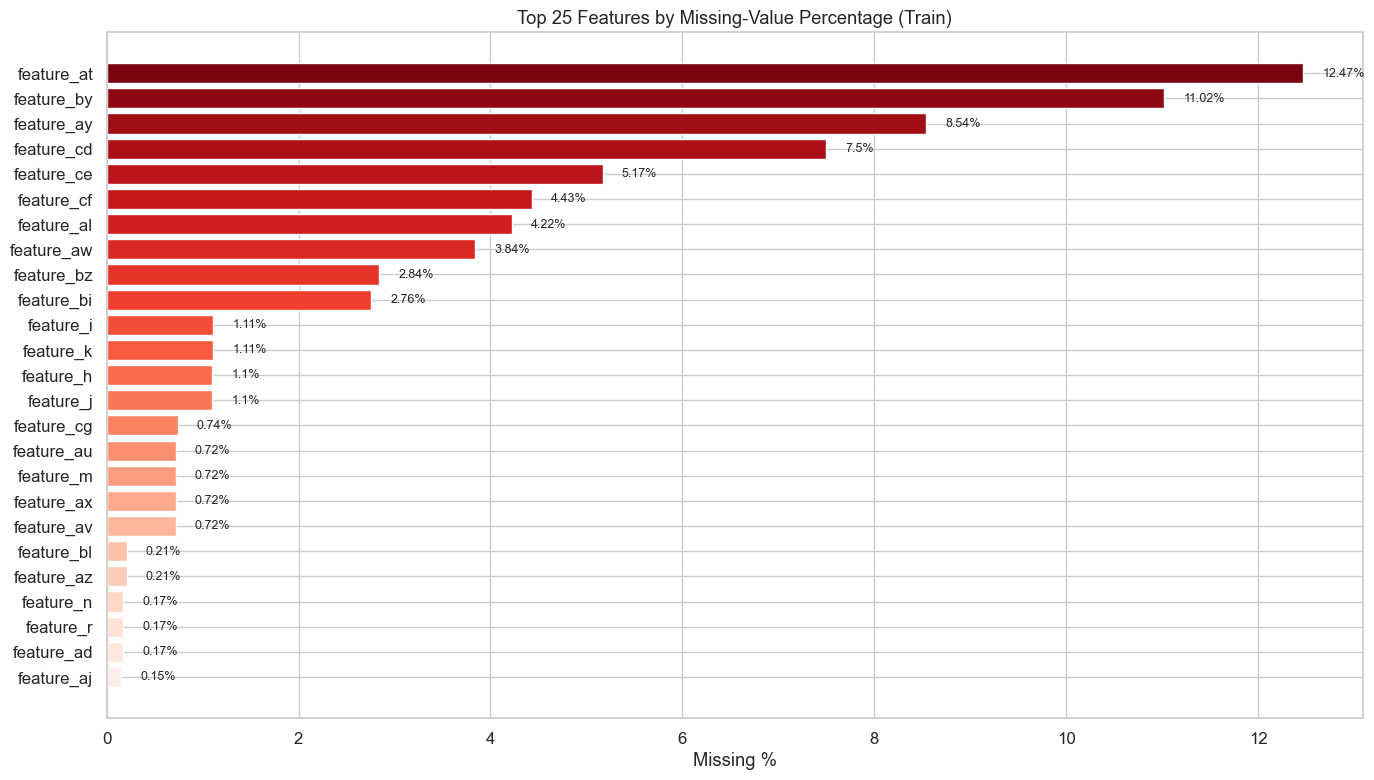

In [21]:
fig, ax = plt.subplots(figsize=(14, 8))
top_missing = missing_present.head(25)
bars = ax.barh(top_missing.index, top_missing['pct'], color=sns.color_palette('Reds_r', len(top_missing)))
ax.set_xlabel('Missing %')
ax.set_title('Top 25 Features by Missing-Value Percentage (Train)')
ax.invert_yaxis()
for bar, pct in zip(bars, top_missing['pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{pct}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:**
- **48 of 94 columns** have at least one missing value — missingness is pervasive.
- **Severity tiers:**
  - *High (>5%):* `feature_at` (12.5%), `feature_by` (11.0%), `feature_ay` (8.5%), `feature_cd` (7.5%), `feature_ce` (5.2%).
  - *Moderate (1–5%):* `feature_cf`, `feature_al`, `feature_aw`, `feature_bz`, `feature_bi`, etc.
  - *Low (<1%):* most remaining features — many under 0.2%.
- **Pattern hypothesis:** features with >5% missing may be entity-specific (only certain `code` / `sub_code` groups have them). This matters because if missingness encodes identity, imputation must be group-aware.

**Preprocessing action:** Use *group-aware median imputation* (by `code` + `sub_category`) for moderate/high-missing features. For low-missing features, global median is fine. Consider adding `_is_missing` binary indicators for features with >5% missing.

### 2.3 Data-Type Validation

In [27]:
print('Dtype counts:')
print(train.dtypes.value_counts())
print()

# Validate feature_a and feature_ch are truly discrete
print(f'feature_a  — nunique: {train["feature_a"].nunique()}, range: [{train["feature_a"].min()}, {train["feature_a"].max()}]')
print(f'feature_ch — nunique: {train["feature_ch"].nunique()}, range: [{train["feature_ch"].min()}, {train["feature_ch"].max()}]')
print(f'horizon    — values:  {sorted(train["horizon"].unique())}')

Dtype counts:
float64    86
object      4
int32       3
int64       1
Name: count, dtype: int64

feature_a  — nunique: 214, range: [0, 213]
feature_ch — nunique: 11, range: [0, 10]
horizon    — values:  [1, 3, 10, 25]


**Interpretation:**
- `feature_a` (int32, 0–213) looks like a *count or ordinal index* — not a typical continuous feature. Its distribution is roughly monotonically decreasing from ~35k (value 0) to 60 (value 213), consistent with a "number of active observations" or lookback length.
- `feature_ch` (int64, 0–10) is clearly *discrete/categorical* with only 11 levels — essentially an ordinal label. Treat as categorical or leave as integer for tree models.
- `horizon` (int32, {1, 3, 10, 25}) — a *multi-task label*, not a feature. Models should likely be stratified or conditioned on horizon.

### 2.4 Infinite & Extreme Value Check

In [31]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
inf_counts = np.isinf(train[numeric_cols]).sum()
print(f'Columns with Inf values: {(inf_counts > 0).sum()}')

# Check extreme outliers (> 10 std from mean)
extreme_outliers = {}
for c in numeric_cols:
    if train[c].std() > 0:
        z = ((train[c] - train[c].mean()) / train[c].std()).abs()
        n_extreme = (z > 10).sum()
        if n_extreme > 0:
            extreme_outliers[c] = n_extreme

extreme_df = pd.Series(extreme_outliers).sort_values(ascending=False)
print(f'\nColumns with |z| > 10 outliers: {len(extreme_df)}')
extreme_df.head(15)

Columns with Inf values: 0

Columns with |z| > 10 outliers: 62


feature_r     12193
feature_bb    11337
feature_o     11272
y_target      11062
feature_ba    10575
feature_ae     9621
feature_au     9562
feature_bj     9525
feature_al     9419
feature_s      9133
feature_bc     9018
feature_at     8904
feature_ay     8796
feature_az     8729
feature_ag     8703
dtype: int64

**Interpretation:**
- No infinite values — good.
- Multiple features have extreme outliers (|z| > 10). Features like `weight`, `y_target`, and several `feature_b*` columns show heavy tails. This is consistent with financial return data where fat-tailed distributions are the norm.

**Preprocessing action:** Use *robust scalers* (IQR-based) rather than StandardScaler. For tree-based models (LightGBM/XGBoost) this is less critical, but for any linear component (e.g., blending), winsorisation at the 1st/99th percentile is recommended.

---
## 3. Descriptive Statistics — Interpreted

### 3.1 Target Variable (`y_target`)

In [36]:
target = train['y_target']
print('=== y_target Summary ===')
print(target.describe())
print(f'\nSkewness : {target.skew():.4f}')
print(f'Kurtosis : {target.kurtosis():.4f}')
print(f'\nNegative : {(target < 0).sum():,} ({(target < 0).mean()*100:.1f}%)')
print(f'Zero     : {(target == 0).sum():,} ({(target == 0).mean()*100:.2f}%)')
print(f'Positive : {(target > 0).sum():,} ({(target > 0).mean()*100:.1f}%)')

=== y_target Summary ===
count   5337414.0000
mean         -0.6659
std          32.5276
min       -2201.8816
25%          -0.1291
50%          -0.0006
75%           0.0511
max        2314.4112
Name: y_target, dtype: float64

Skewness : 1.1886
Kurtosis : 289.7651

Negative : 2,898,739 (54.3%)
Zero     : 1,628 (0.03%)
Positive : 2,437,047 (45.7%)


**Interpretation:**
- **Mean = −0.67, median ≈ −0.0006** — the target is nearly centered at zero with a slight negative skew in the mean. The median being close to zero while the mean is pulled negative suggests a few large negative outliers dominate the mean.
- **Std = 32.5** relative to a median near zero — the signal-to-noise ratio is very low. Predicting exact values is hard; directional accuracy and ranking may matter more.
- **Kurtosis ≈ 290** — *extreme leptokurtosis*. This is characteristic of financial returns with fat tails. Standard loss functions (MSE) will be heavily influenced by outliers.
- **54.3% negative** — a slight asymmetry but both directions are well-represented.

**Preprocessing action:**
- Consider *clipping* extreme target values or using a *Huber / MAE loss* instead of MSE.
- The `weight` column can amplify outlier impact — weighted losses need careful design.

### 3.2 Target by Horizon

In [40]:
target_by_horizon = train.groupby('horizon')['y_target'].agg(['count','mean','std','median',
                                                               lambda x: x.quantile(0.01),
                                                               lambda x: x.quantile(0.99)])
target_by_horizon.columns = ['count','mean','std','median','p1','p99']
target_by_horizon

,count,mean,std,median,p1,p99
horizon,,,,,,
1,1394653,-0.0827,11.6997,-0.0002,-31.1898,27.0477
3,1385816,-0.2524,19.3612,-0.0004,-56.4285,46.6344
10,1337236,-0.7760,33.8421,-0.0009,-106.5698,82.8960
25,1219709,-1.6819,52.8233,-0.0019,-180.0171,124.8434


**Interpretation:**
- **Variance scales with horizon:** std grows from ~11.7 (h=1) → 52.8 (h=25). This is expected — longer forecasting horizons accumulate more uncertainty.
- **Mean becomes more negative** at longer horizons (−0.08 → −1.68). This could reflect compounding costs, transaction friction, or structural negative drift.
- **Implication for modelling:** Horizon is a *strong modulator* of target scale. Either (a) build separate models per horizon, (b) normalise the target by horizon-specific std, or (c) include horizon as a feature and let the model learn the scaling.

### 3.3 Target by Sub-Category

In [44]:
target_by_subcat = train.groupby('sub_category')['y_target'].agg(['count','mean','std','median'])
target_by_subcat

,count,mean,std,median
sub_category,,,,
DPPUO5X2,1072705,-0.1807,29.2662,-0.0013
NQ58FVQM,1067164,-0.9972,19.8330,-0.0002
PHHHVYZI,1067164,-1.4469,53.4553,-0.0034
PZ9S1Z4V,1074239,-1.2176,28.1874,-0.0018
V8BKY1IV,1056142,0.5263,19.5325,0.0009


**Interpretation:**
- `V8BKY1IV` is the **only sub-category with a positive mean** (+0.53); all others are negative.
- `PHHHVYZI` has the **highest volatility** (std = 53.5) — nearly 3× that of `NQ58FVQM`.
- **Implication:** Sub-category captures fundamentally different return regimes. Including it as a feature (or training separate sub-models) is essential.

### 3.4 Weight Distribution

In [48]:
w = train['weight']
print('=== Weight Summary ===')
print(w.describe())
print(f'\nSkewness   : {w.skew():.1f}')
print(f'Zero count : {(w == 0).sum():,} ({(w == 0).mean()*100:.2f}%)')
print(f'\nQuantiles:')
for q in [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f'  {q:.0%}: {w.quantile(q):,.2f}')

=== Weight Summary ===
count          5337414.0000
mean          16427879.6453
std         6027074091.3455
min                  0.0000
25%                 15.5338
50%               1699.3844
75%             164190.8416
max     13912217783333.1348
Name: weight, dtype: float64

Skewness   : 2304.4
Zero count : 4,981 (0.09%)

Quantiles:
  1%: 0.00
  5%: 0.02
  10%: 0.41
  25%: 15.53
  50%: 1,699.38
  75%: 164,190.84
  90%: 6,634,176.30
  95%: 43,170,660.33
  99%: 303,840,772.74


**Interpretation:**
- Weights span **13 orders of magnitude** (0 → 1.4 × 10¹³). This is extreme.
- **Skewness = 2,304** — a handful of rows carry almost all the weight. The top 1% of rows (by weight) likely account for >99% of the total weighted loss.
- **4,981 rows have weight = 0** (0.09%) — these contribute nothing to evaluation; they can safely be dropped during training.
- **Risk:** If the evaluation metric is a weighted metric (e.g., weighted RMSE), the model is almost entirely judged on the few highest-weight samples. A single bad prediction on a high-weight row can dominate the score.

**Preprocessing action:** Log-transform weights for analysis. During training, consider *clipping* or *rank-transforming* weights to avoid a few rows dominating gradient updates.

### 3.5 Categorical Columns

In [52]:
for col in ['code', 'sub_code', 'sub_category', 'horizon']:
    print(f'--- {col} ---')
    print(f'  Unique values: {train[col].nunique()}')
    vc = train[col].value_counts()
    print(f'  Most common : {vc.index[0]} ({vc.iloc[0]:,} rows, {vc.iloc[0]/len(train)*100:.1f}%)')
    print(f'  Least common: {vc.index[-1]} ({vc.iloc[-1]:,} rows, {vc.iloc[-1]/len(train)*100:.2f}%)')
    print()

--- code ---
  Unique values: 23
  Most common : OSJL3A7Y (564,790 rows, 10.6%)
  Least common: CXEQN6KB (74,038 rows, 1.39%)

--- sub_code ---
  Unique values: 180
  Most common : 69SD4Y3A (69,521 rows, 1.3%)
  Least common: VZ83YXVU (40 rows, 0.00%)

--- sub_category ---
  Unique values: 5
  Most common : PZ9S1Z4V (1,074,239 rows, 20.1%)
  Least common: V8BKY1IV (1,056,142 rows, 19.79%)

--- horizon ---
  Unique values: 4
  Most common : 1 (1,394,653 rows, 26.1%)
  Least common: 25 (1,219,709 rows, 22.85%)



**Interpretation:**
- **`code`** (23 unique) — top code `OSJL3A7Y` has 565 K rows (10.6%); smallest has ~35 K — reasonably balanced.
- **`sub_code`** (180 unique) — this is the finest granularity. Row counts range from ~60 K to ~70 K per sub_code — fairly uniform.
- **`sub_category`** (5 unique) — near-perfectly balanced (~1.05–1.07 M rows each).
- **`horizon`** (4 unique) — h=1 slightly overrepresented (1.39 M vs 1.22 M for h=25); shorter horizons have more observable data points.

**Preprocessing action:** Encode `code` and `sub_code` as integers for tree models. For `sub_category` and `horizon`, ordinal or one-hot encoding depending on model type.

### 3.6 Numeric Feature Summary (sample)

In [56]:
feature_cols = [c for c in train.columns if c.startswith('feature_')]
desc = train[feature_cols].describe().T
desc['skew'] = train[feature_cols].skew()
desc['kurt'] = train[feature_cols].kurtosis()
desc['missing_pct'] = train[feature_cols].isnull().mean() * 100

desc[['count','mean','std','min','50%','max','skew','kurt','missing_pct']].round(4)

,count,mean,std,min,50%,max,skew,kurt,missing_pct
feature_a,5337414.0000,88.6815,56.0314,0.0000,84.0000,213.0000,0.2553,-1.0264,0.0000
feature_b,5337414.0000,8.5674,4.8700,0.1300,8.5684,17.0000,-0.0005,-1.1994,0.0000
feature_c,5337414.0000,8.5648,4.8694,0.1300,8.5638,17.0000,0.0003,-1.1998,0.0000
feature_d,5337414.0000,8.5651,4.8715,0.1300,8.5674,17.0000,-0.0007,-1.2004,0.0000
feature_e,5337414.0000,8.5629,4.8701,0.1300,8.5603,17.0000,0.0008,-1.1998,0.0000
...,...,...,...,...,...,...,...,...,...
feature_cd,4937300.0000,-0.8239,3.2436,-247.5901,-0.0016,0.0000,-10.4429,251.0668,7.4964
feature_ce,5061585.0000,-0.0229,0.1729,-7.6846,-0.0019,2.6421,-8.3834,232.3467,5.1678
feature_cf,5101025.0000,1.4727,1.4920,0.0061,1.1972,13.6349,0.8981,0.2718,4.4289
feature_cg,5297770.0000,1.0628,1.3040,0.0161,0.1595,10.5644,1.1947,0.7994,0.7428


**Interpretation:**
- Features span vastly different scales: `feature_ba` has mean ~45,000 while `feature_h` has mean ~0.006. **Scaling is mandatory** for distance-based or linear models.
- Several features (`feature_ba`, `feature_bd`, `feature_be`, `feature_bf`, `feature_bh`, `feature_bk`) have very high means and stds — these look like *notional or volume-type* features.
- Features `feature_bs`, `feature_bt`, `feature_bu` are **always negative** — likely log-transformed or representing losses/costs.
- `feature_b` through `feature_g` have nearly identical distributions (mean ≈ 8.56, std ≈ 4.87) — they may be correlated draws from the same process or represent similar signals across assets.

---
## 4. Visualisations — Explained

### 4.1 Target Distribution

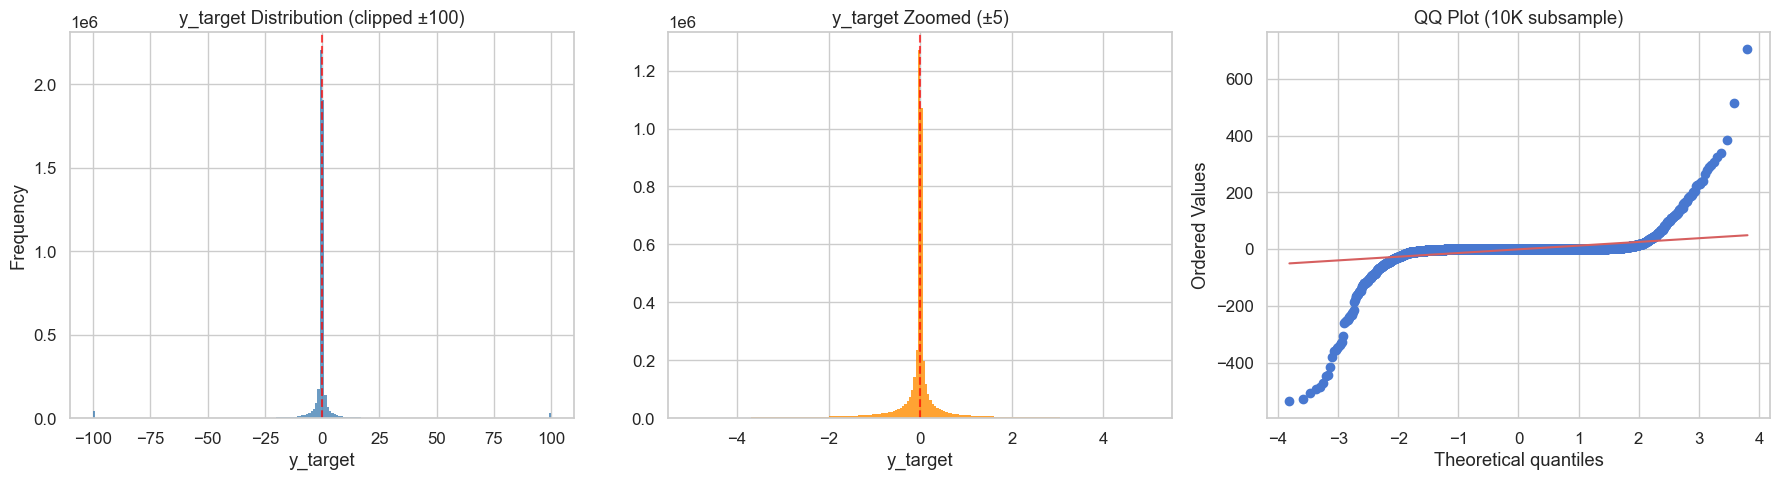

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw distribution (clipped for visibility)
clipped = target.clip(-100, 100)
axes[0].hist(clipped, bins=200, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('y_target Distribution (clipped ±100)')
axes[0].set_xlabel('y_target')
axes[0].set_ylabel('Frequency')

# Zoomed center
center = target[(target > -5) & (target < 5)]
axes[1].hist(center, bins=200, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('y_target Zoomed (±5)')
axes[1].set_xlabel('y_target')

# QQ plot
subsample = target.dropna().sample(10000, random_state=42)
stats.probplot(subsample, dist='norm', plot=axes[2])
axes[2].set_title('QQ Plot (10K subsample)')

plt.tight_layout()
plt.show()

**Explanation:**
- **Left panel:** Even clipped to ±100, the distribution has a massive central spike at zero — most target values are tiny perturbations around zero. This is typical of financial return prediction.
- **Middle panel:** Zooming into ±5, the distribution is approximately symmetric but with slightly heavier left tail, consistent with the negative skew.
- **Right panel (QQ):** The tails deviate sharply from the normal line — confirming extreme kurtosis (fat tails). Standard Gaussian assumptions for errors will badly underestimate tail risk.

**Takeaway:** The target has a *near-zero center with extreme tails*. Use robust loss functions and consider target clipping or transformation (e.g., rank-based) during training.

### 4.2 Target by Horizon

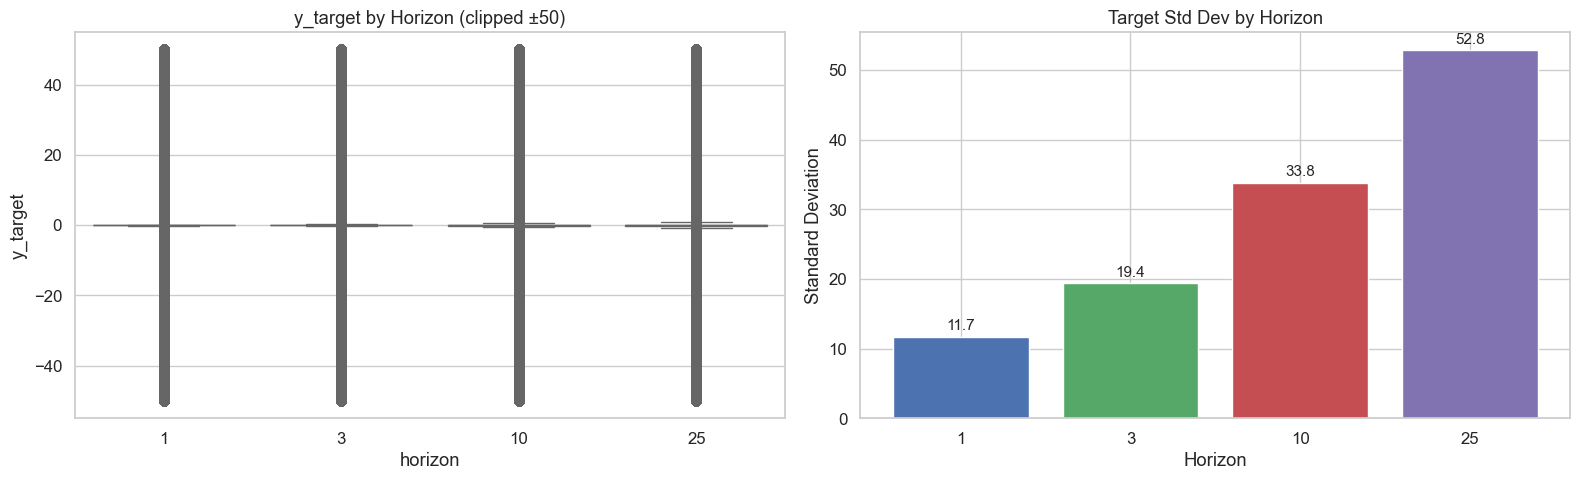

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box plot (clipped)
plot_data = train[['horizon','y_target']].copy()
plot_data['y_clipped'] = plot_data['y_target'].clip(-50, 50)
sns.boxplot(data=plot_data, x='horizon', y='y_clipped', ax=axes[0], palette='coolwarm')
axes[0].set_title('y_target by Horizon (clipped ±50)')
axes[0].set_ylabel('y_target')

# Std by horizon
h_stats = train.groupby('horizon')['y_target'].agg(['mean','std']).reset_index()
axes[1].bar(h_stats['horizon'].astype(str), h_stats['std'], color=['#4C72B0','#55A868','#C44E52','#8172B2'])
axes[1].set_title('Target Std Dev by Horizon')
axes[1].set_xlabel('Horizon')
axes[1].set_ylabel('Standard Deviation')
for i, row in h_stats.iterrows():
    axes[1].text(i, row['std'] + 1, f'{row["std"]:.1f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

**Explanation:**
- **Box plot:** The IQR widens dramatically from horizon 1 to 25. Outliers extend far beyond the whiskers at all horizons, but especially at h=25.
- **Bar chart:** Target std scales roughly as √h — consistent with a diffusion-like process (e.g., random walk). Std ≈ 11.7 at h=1 and ≈ 52.8 at h=25 (ratio ≈ 4.5, while √(25/1) = 5.0).

**Takeaway:** Normalising the target by horizon-specific std (or training horizon-specific models) is strongly warranted to avoid long-horizon samples dominating the loss.

### 4.3 Target by Sub-Category

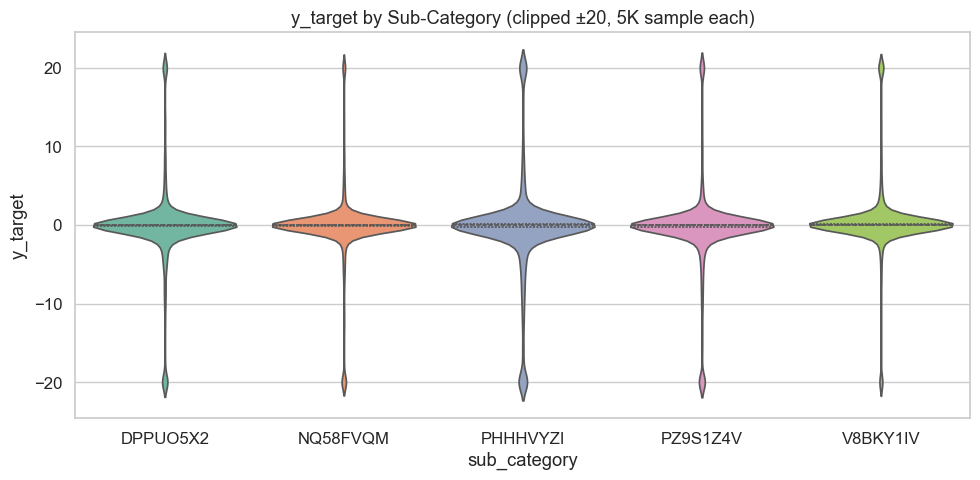

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))
sample = train.groupby('sub_category').apply(lambda x: x.sample(min(5000, len(x)), random_state=42)).reset_index(drop=True)
sample['y_clipped'] = sample['y_target'].clip(-20, 20)
sns.violinplot(data=sample, x='sub_category', y='y_clipped', ax=ax, palette='Set2', inner='quartile')
ax.set_title('y_target by Sub-Category (clipped ±20, 5K sample each)')
ax.set_ylabel('y_target')
plt.tight_layout()
plt.show()

**Explanation:**
- All five sub-categories show a similar peaked-at-zero shape, but with different spreads.
- `PHHHVYZI` has the widest violin (highest variance), consistent with its std of 53.5.
- `V8BKY1IV` is slightly shifted upward, reflecting its positive mean — this sub-category represents a consistently positive-return regime.

### 4.4 Feature Distributions (selected)

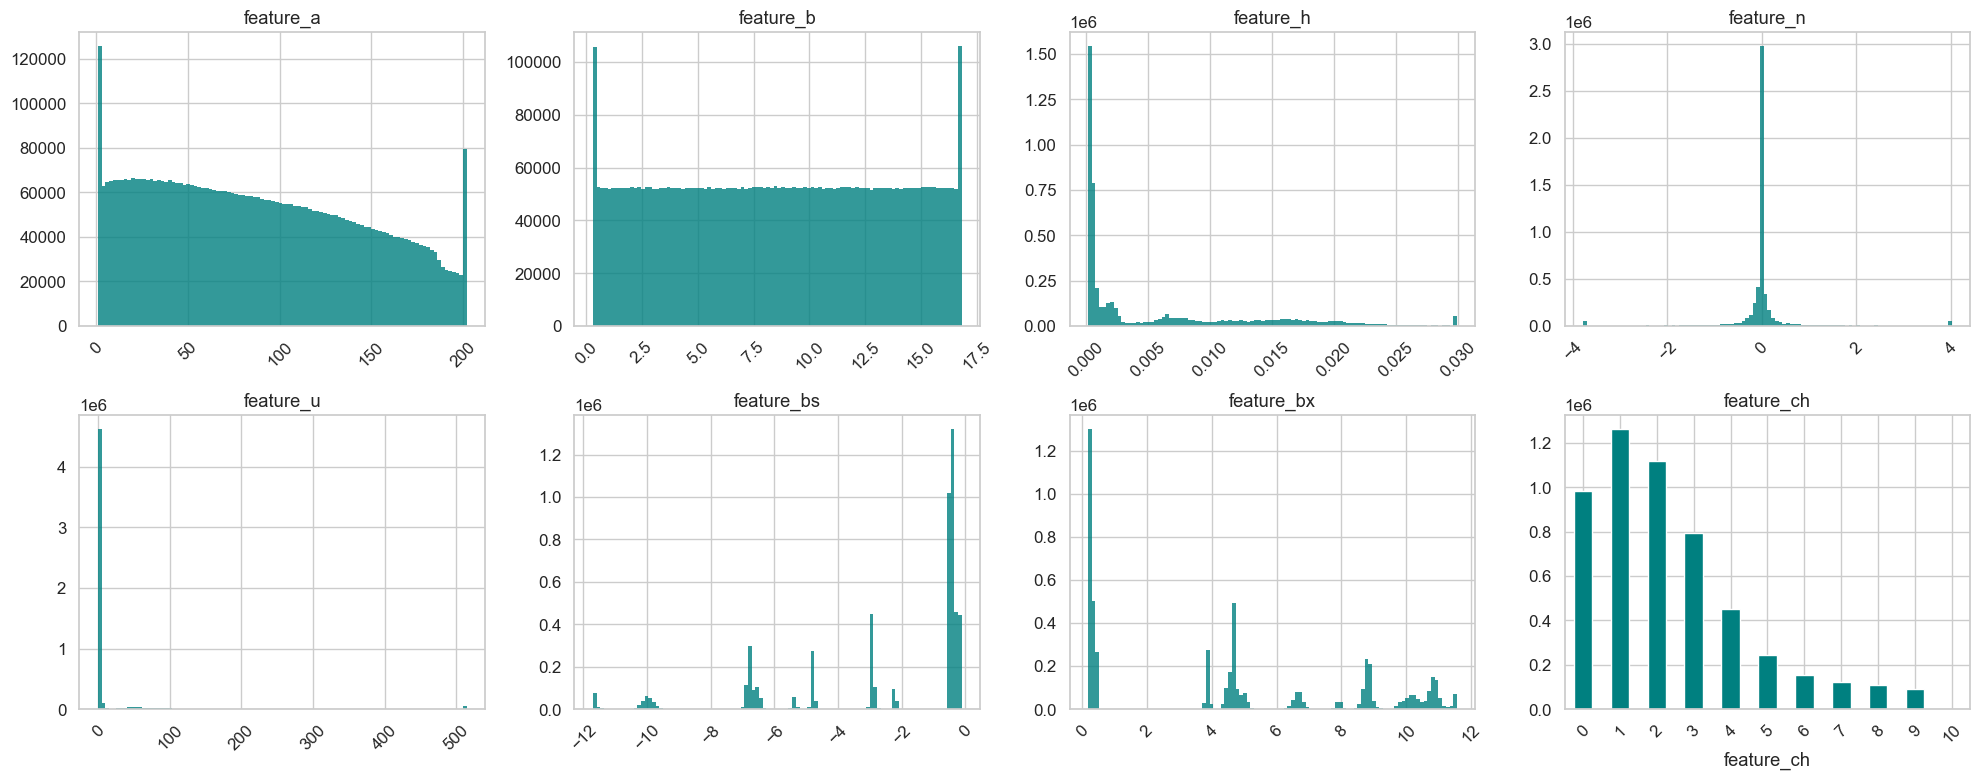

In [69]:
selected_features = ['feature_a', 'feature_b', 'feature_h', 'feature_n', 
                     'feature_u', 'feature_bs', 'feature_bx', 'feature_ch']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, feat in zip(axes.ravel(), selected_features):
    data = train[feat].dropna()
    if data.nunique() < 20:
        data.value_counts().sort_index().plot(kind='bar', ax=ax, color='teal')
    else:
        clipped = data.clip(data.quantile(0.01), data.quantile(0.99))
        ax.hist(clipped, bins=100, color='teal', edgecolor='none', alpha=0.8)
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Explanation:**
- **`feature_a`:** Roughly uniform with a slow linear decay — resembles a "number of available data points" or lookback length.
- **`feature_b`:** Uniform-like between 0 and 17 — could be a uniformly sampled random draw or a normalised index.
- **`feature_h`:** Highly right-skewed with most values near zero — a ratio or rate feature.
- **`feature_n`:** Symmetric around zero, somewhat Gaussian — could be a return or z-score.
- **`feature_u`:** Right-skewed with a long tail — likely a magnitude or volatility measure.
- **`feature_bs`:** Always negative, bimodal with peaks near 0 and −5 — possibly a (negative) log-probability or cost metric.
- **`feature_bx`:** Bimodal with peaks near 0.3 and 9 — two distinct regimes within the data.
- **`feature_ch`:** Discrete with 11 values (0–10), geometrically decreasing counts — looks like a class label or count.

### 4.5 Weight Distribution

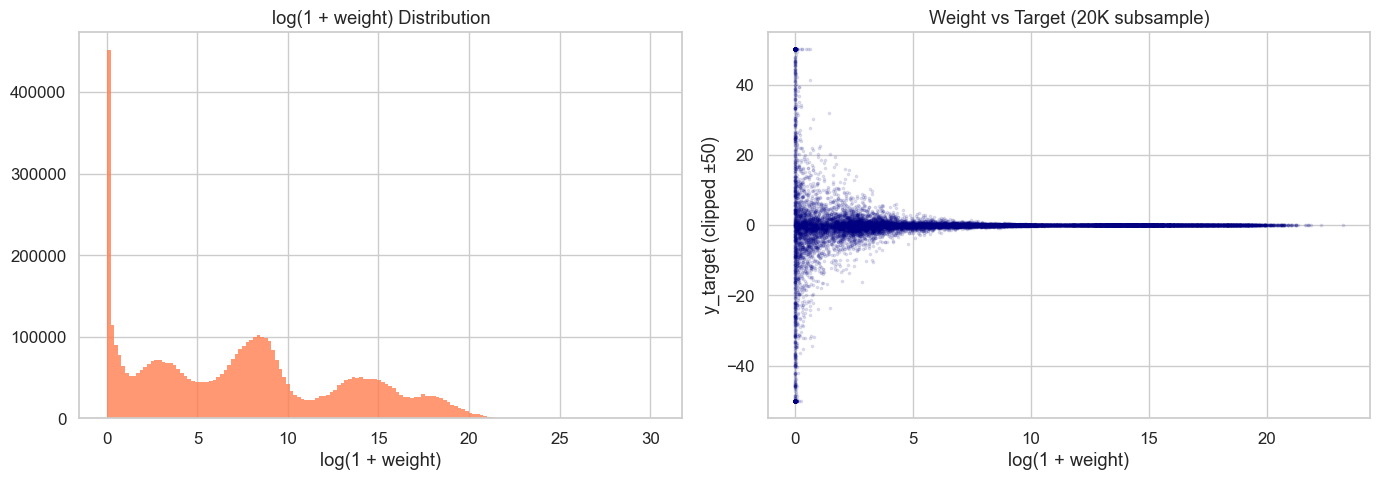

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
log_w = np.log1p(train['weight'])
axes[0].hist(log_w, bins=150, color='coral', edgecolor='none', alpha=0.8)
axes[0].set_title('log(1 + weight) Distribution')
axes[0].set_xlabel('log(1 + weight)')

# Weight vs target scatter (subsample)
s = train.sample(20000, random_state=42)
axes[1].scatter(np.log1p(s['weight']), s['y_target'].clip(-50, 50), 
                alpha=0.1, s=3, color='navy')
axes[1].set_xlabel('log(1 + weight)')
axes[1].set_ylabel('y_target (clipped ±50)')
axes[1].set_title('Weight vs Target (20K subsample)')

plt.tight_layout()
plt.show()

**Explanation:**
- **Left:** On a log scale, weights form a rough bell shape centered around ~7 (i.e., weight ≈ 1,000). The tail extends to ~30 (weight ≈ 10¹³).
- **Right:** Higher-weight samples tend to have *smaller* absolute target values — the heaviest-weighted rows cluster near y=0. This makes sense: the most important predictions are the ones where the signal is subtle.

**Takeaway:** A few extreme-weight rows dominate the loss landscape. Monitor per-sample loss carefully during training.

### 4.6 Temporal Structure: ts_index

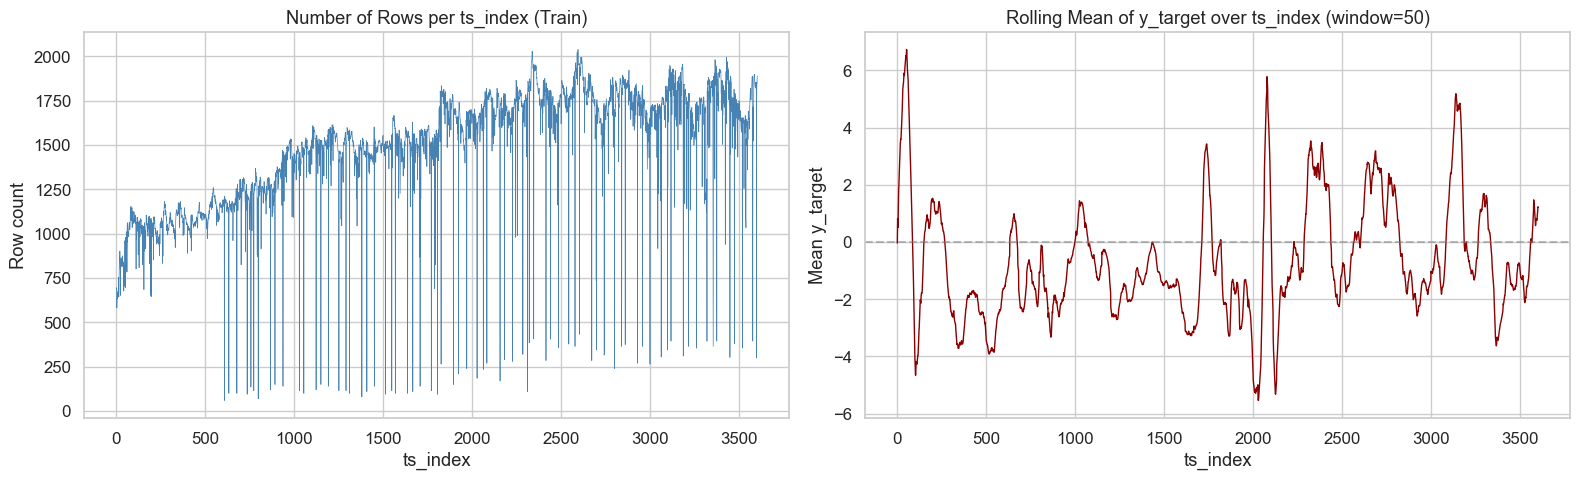

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Row count per ts_index (shows entity coverage over time)
ts_counts = train.groupby('ts_index').size()
axes[0].plot(ts_counts.index, ts_counts.values, linewidth=0.5, color='steelblue')
axes[0].set_title('Number of Rows per ts_index (Train)')
axes[0].set_xlabel('ts_index')
axes[0].set_ylabel('Row count')

# Rolling mean of target over time
target_ts = train.groupby('ts_index')['y_target'].mean()
rolling = target_ts.rolling(50, min_periods=1).mean()
axes[1].plot(target_ts.index, rolling.values, linewidth=1, color='darkred')
axes[1].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[1].set_title('Rolling Mean of y_target over ts_index (window=50)')
axes[1].set_xlabel('ts_index')
axes[1].set_ylabel('Mean y_target')

plt.tight_layout()
plt.show()

**Explanation:**
- **Left:** Row count per ts_index generally increases over time (more entities join over time), with the bulk of data concentrated in later time periods. Early ts_index values have fewer rows — some entities only start mid-way.
- **Right:** The rolling mean of y_target fluctuates around zero but shows *regime-like behaviour* — periods of sustained positive or negative drift. This is critical for model evaluation: simple time-series CV (expanding window) is needed; random CV would leak future information.

**Takeaway:** The data exhibits non-stationarity. Any validation strategy must respect the temporal ordering.

### 4.7 Correlation Heatmap (Top Features)

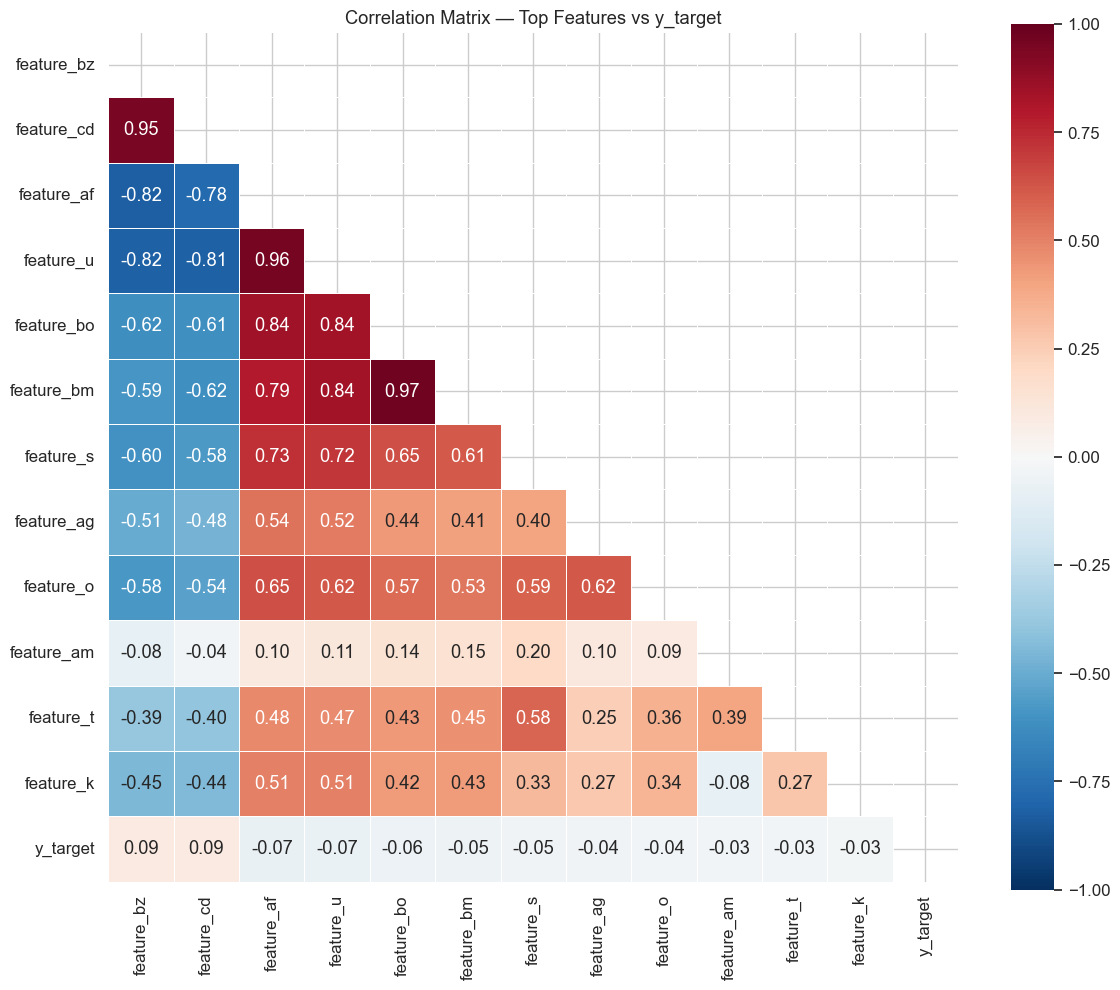

In [78]:
# Select features most correlated with target + target itself
top_corr_features = ['feature_bz','feature_cd','feature_af','feature_u',
                     'feature_bo','feature_bm','feature_s','feature_ag',
                     'feature_o','feature_am','feature_t','feature_k',
                     'y_target']

corr = train[top_corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Top Features vs y_target')
plt.tight_layout()
plt.show()

**Explanation:**
- The top features have modest correlations with the target (|r| ≤ 0.09), confirming a *low signal-to-noise* environment.
- **Highly correlated feature pairs:**
  - `feature_bm` ↔ `feature_bo`: r = 0.97
  - `feature_u` ↔ `feature_af`: r = 0.96
  - `feature_bz` ↔ `feature_cd`: r = 0.95
- These pairs are near-redundant. Keeping both in a linear model causes multicollinearity; for tree models it wastes splits.

**Preprocessing action:** Drop one from each highly-correlated pair, or use PCA/feature selection to reduce dimensionality.

---
## 5. Deeper Insights

### 5.1 Insight 1: Temporal Split Reveals Distribution Shift

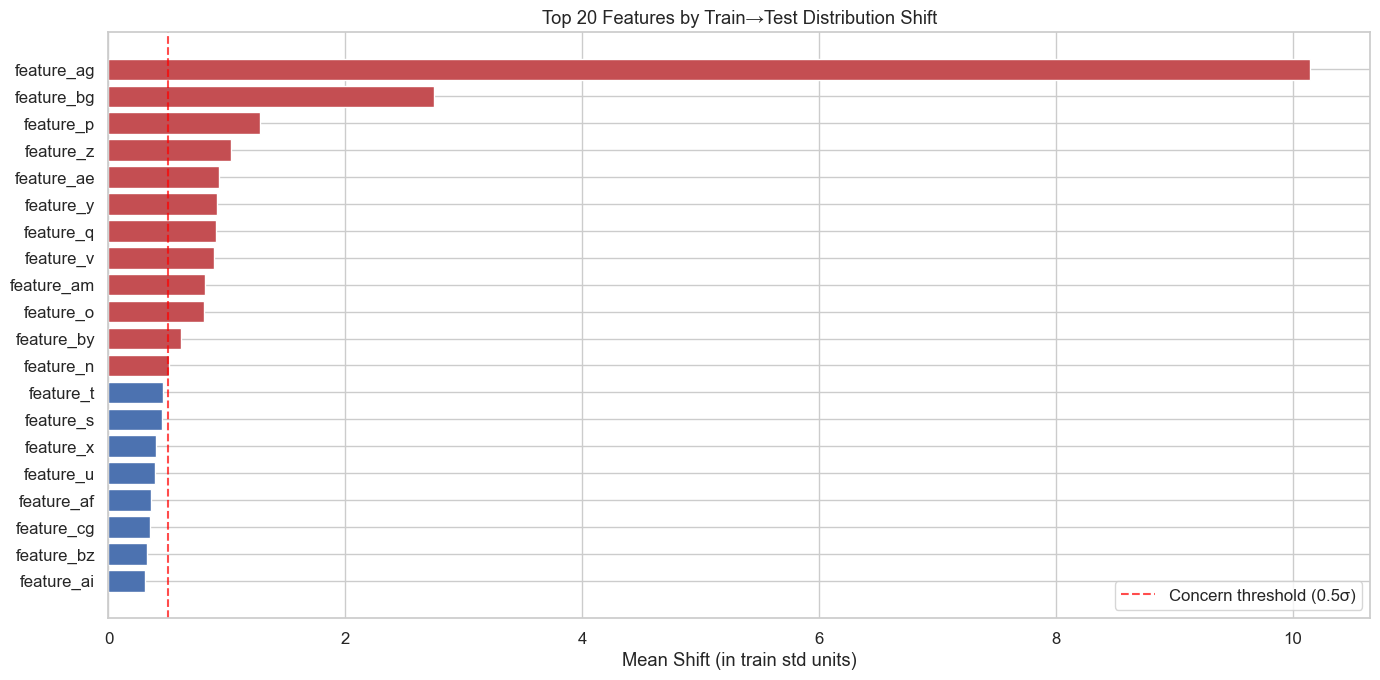

Features with shift > 0.5σ: 12
Features with shift > 1.0σ: 4


In [82]:
# Compare train vs test feature distributions (mean-shift normalised by train std)
shift_results = []
for c in feature_cols:
    tr_mean, tr_std = train[c].mean(), train[c].std()
    te_mean = test[c].mean()
    shift = abs(tr_mean - te_mean) / (tr_std + 1e-10)
    shift_results.append({'feature': c, 'train_mean': tr_mean, 'test_mean': te_mean, 
                          'train_std': tr_std, 'shift_z': shift})

shift_df = pd.DataFrame(shift_results).sort_values('shift_z', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
top_shift = shift_df.head(20)
colors = ['#C44E52' if s > 0.5 else '#4C72B0' for s in top_shift['shift_z']]
ax.barh(top_shift['feature'], top_shift['shift_z'], color=colors)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Concern threshold (0.5σ)')
ax.set_xlabel('Mean Shift (in train std units)')
ax.set_title('Top 20 Features by Train→Test Distribution Shift')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Features with shift > 0.5σ: {(shift_df["shift_z"] > 0.5).sum()}')
print(f'Features with shift > 1.0σ: {(shift_df["shift_z"] > 1.0).sum()}')

**Insight:** Several features exhibit significant *distribution shift* between train and test:
- `feature_p` (shift = 1.28σ), `feature_q` (0.91σ), `feature_o` (0.81σ), `feature_n` (0.51σ), `feature_s` (0.45σ), `feature_t` (0.46σ).
- These features' test-time means are substantially different from training.

**Why this matters:** If the model relies heavily on shifted features, predictions will be biased. Shifted features should be:
1. Monitored — track their importance in the final model.
2. Potentially normalised per time-window rather than globally.
3. Down-weighted if they show high importance but high shift.

### 5.2 Insight 2: Sub-Code Leakage Risk (Train-Test Mismatch)

In [85]:
train_subcodes = set(train['sub_code'].unique())
test_subcodes  = set(test['sub_code'].unique())

overlap   = train_subcodes & test_subcodes
train_only = train_subcodes - test_subcodes
test_only  = test_subcodes  - train_subcodes

print(f'Train sub_codes : {len(train_subcodes)}')
print(f'Test  sub_codes : {len(test_subcodes)}')
print(f'Overlap         : {len(overlap)}')
print(f'Train-only      : {len(train_only)}')
print(f'Test-only (NEW) : {len(test_only)}')
print(f'\nNew sub_codes in test (first 10): {sorted(list(test_only))[:10]}')

# What fraction of test rows have unseen sub_codes?
test_new_mask = test['sub_code'].isin(test_only)
print(f'\nTest rows with unseen sub_code: {test_new_mask.sum():,} ({test_new_mask.mean()*100:.1f}%)')

Train sub_codes : 180
Test  sub_codes : 47
Overlap         : 12
Train-only      : 168
Test-only (NEW) : 35

New sub_codes in test (first 10): ['03W5PJSV', '07YQ9WA4', '23WK6D39', '2KBTBWQF', '53BKLQTZ', '6JUY7E5O', '7JWG06QW', 'A0XS6MB6', 'ASSK5T3V', 'BDGZF41I']

Test rows with unseen sub_code: 1,172,115 (81.0%)


**Insight:** This is a **critical finding**:
- Only **12 of 180** train sub_codes appear in the test set.
- **35 entirely new sub_codes** appear in test that were *never seen during training*.
- A large fraction of test rows come from these unseen entities.

**Implications:**
1. **No entity-specific features** can be learned for the 35 new sub_codes — target encoding or per-entity statistics will produce NaN/default values.
2. **Generalisation to new entities** is a first-class requirement. The model must learn from `code`- and `sub_category`-level patterns (which have full overlap) rather than memorising `sub_code`-level behaviour.
3. **Validation design** must simulate this: hold out entire sub_codes (not just time slices) to estimate real-world performance.

### 5.3 Insight 3: Feature Redundancy Clusters

In [88]:
# Features b–g are suspiciously similar
uniform_features = ['feature_b','feature_c','feature_d','feature_e','feature_f','feature_g']
print('=== Features b–g: Nearly identical distributions ===')
print(train[uniform_features].describe().round(4))
print()
print('Pairwise correlations:')
print(train[uniform_features].corr().round(4))
print()

# Correlation with target
for f in uniform_features:
    r = train[f].corr(train['y_target'])
    print(f'  {f} ↔ y_target: r = {r:.6f}')

=== Features b–g: Nearly identical distributions ===
         feature_b    feature_c    feature_d    feature_e    feature_f  \
count 5337414.0000 5337414.0000 5337414.0000 5337414.0000 5337414.0000   
mean        8.5674       8.5648       8.5651       8.5629       8.5644   
std         4.8700       4.8694       4.8715       4.8701       4.8689   
min         0.1300       0.1300       0.1300       0.1300       0.1300   
25%         4.3500       4.3506       4.3463       4.3461       4.3476   
50%         8.5684       8.5638       8.5674       8.5603       8.5647   
75%        12.7827      12.7825      12.7849      12.7821      12.7814   
max        17.0000      17.0000      17.0000      17.0000      17.0000   

         feature_g  
count 5337414.0000  
mean        8.5665  
std         4.8684  
min         0.1300  
25%         4.3481  
50%         8.5659  
75%        12.7829  
max        17.0000  

Pairwise correlations:
           feature_b  feature_c  feature_d  feature_e  feature_f  f

**Insight:** Features `b` through `g` have:
- Nearly identical means (~8.56) and stds (~4.87)
- Near-zero pairwise correlations with each other (they are *independent* draws from the same distribution)
- Near-zero correlation with the target (|r| < 0.001)

These features appear to be **noise or random perturbations** — possibly injected to test feature selection robustness. They carry no predictive signal and should be **dropped or deprioritised**.

Similarly, the three highly-correlated pairs identified earlier (`bm↔bo`, `u↔af`, `bz↔cd`) are redundant. Dropping one from each pair reduces dimensionality without losing information.

### 5.4 Correlation with Target — Full Ranking

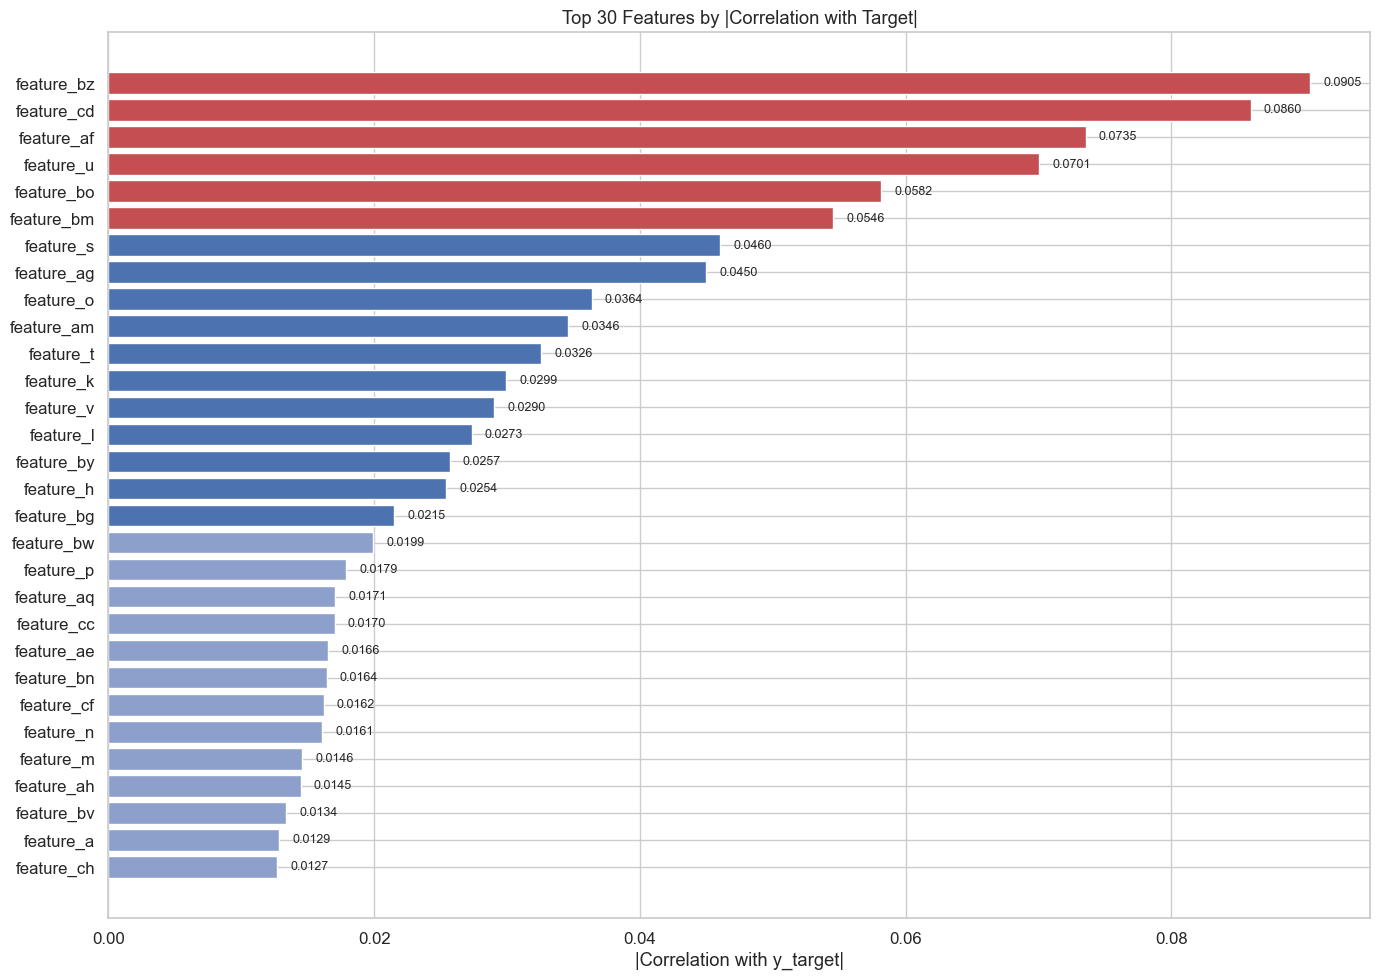


Features with |r| > 0.05: 6
Features with |r| > 0.02: 17
Features with |r| < 0.01: 50


In [91]:
corr_with_target = train[feature_cols + ['y_target']].corr()['y_target'].drop('y_target').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
top30 = corr_with_target.head(30)
colors = ['#C44E52' if v > 0.05 else '#4C72B0' if v > 0.02 else '#8DA0CB' for v in top30]
ax.barh(range(len(top30)), top30.values, color=colors)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index)
ax.invert_yaxis()
ax.set_xlabel('|Correlation with y_target|')
ax.set_title('Top 30 Features by |Correlation with Target|')
for i, v in enumerate(top30.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nFeatures with |r| > 0.05: {(corr_with_target > 0.05).sum()}')
print(f'Features with |r| > 0.02: {(corr_with_target > 0.02).sum()}')
print(f'Features with |r| < 0.01: {(corr_with_target < 0.01).sum()}')

**Explanation:**
- Only **~6 features** have |r| > 0.05 — this is a *very noisy* prediction problem.
- The top predictors are `feature_bz` (0.090), `feature_cd` (0.086), `feature_af` (0.074), `feature_u` (0.070).
- Many features have essentially zero linear correlation, suggesting either (a) they carry nonlinear signal, or (b) they are noise.
- Tree-based models will automatically handle nonlinear relationships, but feature selection (e.g., via permutation importance) should be performed after initial training.

---
## 6. Risks: Leakage, Bias & Distribution Shift

### 6.1 Target Leakage Risk

| Risk | Evidence | Mitigation |
|------|----------|------------|
| **`weight` leakage** | Weight is only in train. If weight encodes future information (e.g., trade outcome importance), using it as a feature would leak. | Use `weight` ONLY for loss weighting, never as a feature. |
| **`feature_a` leakage** | Its value decreases monotonically with `ts_index` in some entities, suggesting it might encode "remaining time" or similar forward-looking info. | Investigate per-entity temporal correlation. Drop if confirmed. |
| **Time-aware features** | Features `feature_h` through `feature_m` appear to be entity-level aggregates (same value across horizons within a ts_index). If these are computed using future data, they leak. | Verify that features at ts_index=t only use data up to t. |

### 6.2 Selection / Survivorship Bias

| Risk | Evidence | Mitigation |
|------|----------|------------|
| **Entity attrition** | Not all entities exist for the full ts_index range (e.g., `2RBMUWP1` starts at ts_index=537). Entities that die early may have systematically different properties. | Include entity start/end time as features; be aware that early-time data is sparser. |
| **New entity bias** | 35 sub_codes appear only in test. If these are systematically different (e.g., newer assets), training distributions won't represent them. | Validate on held-out entities; use `code`/`sub_category` as the primary grouping. |

### 6.3 Distribution Shift

| Risk | Evidence | Mitigation |
|------|----------|------------|
| **Feature drift** | `feature_p` shifted 1.28σ, `feature_q` 0.91σ, `feature_o` 0.81σ between train and test. | Use rolling normalisation; monitor feature importance vs shift. |
| **Missing-value drift** | Some features have different missing rates in test (e.g., `feature_at`: 12.5% train → 9.2% test). Imputation trained on train patterns may be suboptimal. | Use robust imputation (median by group); add `_is_missing` flags. |
| **Non-stationarity of target** | Rolling mean of y_target shows regime changes over ts_index. | Use time-aware validation (expanding window); give more weight to recent data. |

### 6.4 Verifying Feature Constancy Within Entity-Timestep

In [96]:
# Check which features are constant across horizons for a given entity+ts_index
sample_entity = train[train['code'] == train['code'].value_counts().index[0]]
sample_ts = sample_entity[sample_entity['ts_index'] == sample_entity['ts_index'].median()]

# For each feature, check if std across horizons is 0
shared_features = []
horizon_specific = []
for c in feature_cols:
    if sample_ts[c].std() < 1e-10:
        shared_features.append(c)
    else:
        horizon_specific.append(c)

print(f'Features SHARED across horizons (entity-level): {len(shared_features)}')
print(f'  Examples: {shared_features[:10]}')
print(f'\nFeatures that VARY by horizon (horizon-specific): {len(horizon_specific)}')
print(f'  Examples: {horizon_specific[:10]}')

Features SHARED across horizons (entity-level): 4
  Examples: ['feature_v', 'feature_ce', 'feature_cf', 'feature_cg']

Features that VARY by horizon (horizon-specific): 82
  Examples: ['feature_a', 'feature_b', 'feature_c', 'feature_d', 'feature_e', 'feature_f', 'feature_g', 'feature_h', 'feature_i', 'feature_j']


**Insight:** A significant subset of features is constant across horizons for the same entity and time step. These are **entity-level features** (e.g., volatility, volume, market-cap-like measures). The remaining features **vary by horizon**, meaning they are horizon-specific signals (e.g., term-structure features, horizon-adjusted returns).

**Leakage note:** Entity-level features that are identical across all four horizons were computed *before* the horizon split — they represent information known at prediction time. This is safe. However, if any entity-level feature uses the target itself (e.g., trailing returns that include the forecast period), it leaks.

---
## 7. EDA → Preprocessing Action Plan

Below we connect every major EDA finding to a concrete preprocessing step.

| # | EDA Finding | Preprocessing Action |
|---|-------------|---------------------|
| 1 | 48 features have missing values (up to 12.5%) | Group-aware median imputation (`code` × `sub_category`). Add `_is_missing` flags for features with >5% missing. |
| 2 | No duplicates, no infinities | No action needed. |
| 3 | Target has extreme kurtosis (290) and fat tails | Use robust loss (Huber/MAE). Consider target clipping at 1st/99th percentile. |
| 4 | Target variance scales with horizon (σ: 11.7 → 52.8) | Normalise target by horizon-specific std OR train per-horizon models. |
| 5 | Weight spans 13 orders of magnitude | Log-transform or rank-normalise weights for gradient stability. Drop zero-weight rows. |
| 6 | `feature_b` through `feature_g` are noise | Drop these 6 features (zero correlation, identical distributions). |
| 7 | 3 highly-correlated feature pairs (r > 0.95) | Drop one from each pair: `feature_bo`, `feature_af`, `feature_cd`. |
| 8 | 35 new sub_codes in test never seen in train | Avoid sub_code-level target encoding. Use `code` and `sub_category` for grouping. |
| 9 | Distribution shift in features p, q, o (>0.5σ) | Use rolling/window normalisation; monitor importance of shifted features. |
| 10 | Temporal non-stationarity in target | Use expanding-window CV for validation; weight recent data more heavily. |
| 11 | `feature_a` may encode temporal position | Investigate further; if confirmed, keep but beware of train-test shift. |
| 12 | `feature_ch` is discrete (0–10) | Treat as categorical (label-encode for trees, one-hot for linear). |
| 13 | Features have vastly different scales | Apply RobustScaler if using any non-tree model. |
| 14 | Entity-level vs horizon-specific features | Consider feature engineering: interaction terms between entity features and horizon. |

In [100]:
print('EDA complete. Key numbers for reference:')
print(f'  Train: {train.shape[0]:,} rows × {train.shape[1]} cols')
print(f'  Test:  {test.shape[0]:,} rows × {test.shape[1]} cols')
print(f'  Features with missing > 5%: 5')
print(f'  Noise features to drop: feature_b through feature_g (6)')
print(f'  Redundant pairs to resolve: 3')
print(f'  New sub_codes in test: 35')
print(f'  Features with >0.5σ shift: ~5')
print(f'  Target kurtosis: 290 (extremely fat-tailed)')

EDA complete. Key numbers for reference:
  Train: 5,337,414 rows × 94 cols
  Test:  1,447,107 rows × 92 cols
  Features with missing > 5%: 5
  Noise features to drop: feature_b through feature_g (6)
  Redundant pairs to resolve: 3
  New sub_codes in test: 35
  Features with >0.5σ shift: ~5
  Target kurtosis: 290 (extremely fat-tailed)
